In [1]:
import os
from dataclasses import dataclass
from typing import Tuple
import pytorch_lightning as pl
import pandas as pd
import torch
from IPython.display import display
from lightning.pytorch.loggers import CSVLogger
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split, TensorDataset
from torchmetrics.classification import BinaryAccuracy, BinaryROC
import numpy as np
from torch.utils.data import WeightedRandomSampler
import seaborn as sn
from torchmetrics.classification import BinaryConfusionMatrix
import shap

/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!nvidia-smi

Tue Nov  7 05:46:45 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A4000    On   | 00000000:01:00.0 Off |                  Off |
| 43%   61C    P2    66W / 140W |   4157MiB / 16376MiB |    100%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A4000    On   | 00000000:C1:00.0 Off |                  Off |
| 42%   

In [3]:
author_references = pd.read_hdf('author_references_Nov1_balanced.h5')

In [4]:
@dataclass
class Config:
    """Configuration options for the Lightning MNIST example.

    Args:
        data_dir : The path to the directory where the MNIST dataset is stored. Defaults to the value of
            the 'PATH_DATASETS' environment variable or '.' if not set.

        save_dir : The path to the directory where the training logs will be saved. Defaults to 'logs/'.

        batch_size : The batch size to use during training. Defaults to 256 if a GPU is available,
            or 64 otherwise.

        max_epochs : The maximum number of epochs to train the model for. Defaults to 3.

        accelerator : The accelerator to use for training. Can be one of "cpu", "gpu", "tpu", "ipu", "auto".

        devices : The number of devices to use for training. Defaults to 1.

    Examples:
        This dataclass can be used to specify the configuration options for training a PyTorch Lightning model on the
        MNIST dataset. A new instance of this dataclass can be created as follows:

        >>> config = Config()

        The default values for each argument are shown in the documentation above. If desired, any of these values can be
        overridden when creating a new instance of the dataclass:

        >>> config = Config(batch_size=128, max_epochs=5)
    """

    #data_dir: str = os.environ.get("PATH_DATASETS", ".")
    save_dir: str = "logs/"
    #batch_size: int = 256 if torch.cuda.is_available() else 64
    #max_epochs: int = 3
    #accelerator: str = "auto"
    #devices: int = 1


config = Config()

In [5]:
# @dataclass
# class Config:
#     data_dir: str = os.environ.get("PATH_DATASETS", ".")
#     save_dir: str = "logs/"
#     batch_size: int = 256 if torch.cuda.is_available() else 64
#     max_epochs: int = 3
#     accelerator: str = "auto"
#     devices: int = 1
#     num_layers: int = 3  # Number of layers in your neural network
#     activation_function: str = "relu"  # Activation function to use (e.g., 'relu', 'sigmoid', etc.)
#     num_neurons: int = 128  # Number of neurons in each layer

# # Create an instance of the Config class
# config = Config()


In [6]:
aff1_chars2vec_1 = np.load('aff1_embeddings_1.npy')
aff1_chars2vec_2 = np.load('aff1_embeddings_2.npy')
aff1_chars2vec_3 = np.load('aff1_embeddings_3.npy')
aff2_chars2vec_1 = np.load('aff2_embeddings_1.npy')
aff2_chars2vec_2 = np.load('aff2_embeddings_2.npy')
aff2_chars2vec_3 = np.load('aff2_embeddings_3.npy')

In [7]:
aff1_chars2vec = np.concatenate((aff1_chars2vec_1, aff1_chars2vec_2, aff1_chars2vec_3), axis = 0)
aff2_chars2vec = np.concatenate((aff2_chars2vec_1, aff2_chars2vec_2, aff2_chars2vec_3), axis = 0)
# aff1_chars2vec = np.load('aff1_embeddings.npy')
# aff2_chars2vec = np.load('aff2_embeddings.npy')

In [8]:
#author1_chars2vec = np.concatenate((np.load('author1_embeddings_0.npy'), np.load('author1_embeddings_1.npy')), axis=0)
#author2_chars2vec = np.concatenate((np.load('author2_embeddings_0.npy'), np.load('author2_embeddings_1.npy')), axis=0)
# author1_chars2vec = np.load('author1_embeddings.npy')
# author2_chars2vec = np.load('author2_embeddings.npy')
author1_chars2vec = np.load('author1_embeddings_150.npy')
author2_chars2vec = np.load('author2_embeddings_150.npy')

In [9]:
author1_specter = torch.load('author1_embeddings_specter.pth', map_location='cpu')
author2_specter = torch.load('author2_embeddings_specter.pth', map_location='cpu')
author1_np_specter = author1_specter.detach().cpu().numpy()
author2_np_specter = author2_specter.detach().cpu().numpy()

In [10]:
# author1_specter = torch.cat([torch.load('author1_embeddings_1_specter.pth', map_location='cpu'),
#                              torch.load('author1_embeddings_2_specter.pth', map_location='cpu')], axis = 1)
# author2_specter = torch.cat([torch.load('author2_embeddings_1_specter.pth', map_location='cpu'),
#                              torch.load('author2_embeddings_2_specter.pth', map_location='cpu')], axis = 1)
# author1_np_specter = author1_specter.detach().cpu().numpy()
# author2_np_specter = author2_specter.detach().cpu().numpy()

In [11]:
!nvidia-smi

Tue Nov  7 05:46:46 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A4000    On   | 00000000:01:00.0 Off |                  Off |
| 43%   61C    P2    66W / 140W |   4157MiB / 16376MiB |    100%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A4000    On   | 00000000:C1:00.0 Off |                  Off |
| 42%   

In [12]:
import gc
torch.cuda.empty_cache()
gc.collect()

108

In [13]:
#device = author1_specter.device

In [14]:
# To load the embeddings back later, you can use torch.load
#author1_chars2vec = torch.tensor(author1_chars2vec, dtype=torch.float32).to(device)
#aff1_chars2vec = torch.tensor(aff1_chars2vec, dtype=torch.float32).to(device)
#author2_chars2vec = torch.tensor(author2_chars2vec, dtype=torch.float32).to(device)
#aff2_chars2vec = torch.tensor(aff2_chars2vec, dtype=torch.float32).to(device)

In [15]:
author1_embed = np.concatenate([author1_np_specter, author1_chars2vec,aff1_chars2vec], axis =1)
author2_embed = np.concatenate([author2_np_specter, author2_chars2vec,aff2_chars2vec], axis =1)

In [33]:
class ANDDataModule(pl.LightningDataModule):
    def __init__(self, data_dir: str = "path/to/dir", batch_size: int = 512):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.data =  TensorDataset(torch.cat([torch.unsqueeze(torch.tensor(author1_embed, dtype = torch.float32), axis = 1),
               torch.unsqueeze(torch.tensor(author2_embed, dtype = torch.float32), axis = 1)], axis = 1),
               torch.tensor(author_references.label.to_list(), dtype=torch.bool))
    def setup(self, stage: str):
        self.specter_train, self.specter_val, self.specter_test = random_split(self.data, [20000, 4500, 500])
        # Calculate class weights for weighted random sampler
        labels = [label.item() for _, label in self.specter_train]
        
        class_counts = torch.bincount(torch.tensor(labels, dtype=torch.int64))

        # Number of samples you want to sample
        num_samples = len(labels)

        # Weights for each sample
        weights = [1.0 / class_counts[i] for i in range(len(class_counts))]

        # List to contain the weights of each sample
        sample_weights = []

        for idx, label in enumerate(labels):
            class_weight = weights[label]
            sample_weights.append(class_weight)

        self.sampler = WeightedRandomSampler(sample_weights, num_samples)

    def train_dataloader(self):
        return DataLoader(self.specter_train, batch_size=self.batch_size, num_workers=0, sampler=self.sampler)

    def val_dataloader(self):
        return DataLoader(self.specter_val, batch_size=self.batch_size, num_workers=0)

    def test_dataloader(self):
        return DataLoader(self.specter_test, batch_size=self.batch_size, num_workers=0)

In [34]:
# class ANDDataModule(pl.LightningDataModule):
#     def __init__(self, data_dir: str = "path/to/dir", batch_size: int = 512):
#         super().__init__()
#         self.data_dir = data_dir
#         self.batch_size = batch_size
#         self.data =  TensorDataset(torch.cat([torch.tensor(author1_embed, dtype = torch.float32),
#                torch.tensor(author2_embed, dtype = torch.float32)], axis = 1),
#                torch.tensor(author_references.label.to_list(), dtype=torch.bool))
#     def setup(self, stage: str):
#         self.specter_train, self.specter_val, self.specter_test = random_split(self.data, [20000, 4500, 500])
#         # Calculate class weights for weighted random sampler
#         labels = [label.item() for _, label in self.specter_train]
        
#         class_counts = torch.bincount(torch.tensor(labels, dtype=torch.int64))

#         # Number of samples you want to sample
#         num_samples = len(labels)

#         # Weights for each sample
#         weights = [1.0 / class_counts[i] for i in range(len(class_counts))]

#         # List to contain the weights of each sample
#         sample_weights = []

#         for idx, label in enumerate(labels):
#             class_weight = weights[label]
#             sample_weights.append(class_weight)

#         self.sampler = WeightedRandomSampler(sample_weights, num_samples)

#     def train_dataloader(self):
#         return DataLoader(self.specter_train, batch_size=self.batch_size, num_workers=0, sampler=self.sampler)

#     def val_dataloader(self):
#         return DataLoader(self.specter_val, batch_size=self.batch_size, num_workers=0)

#     def test_dataloader(self):
#         return DataLoader(self.specter_test, batch_size=self.batch_size, num_workers=0)

In [35]:
dataset = ANDDataModule()

In [36]:
#dataset.prepare_data()
dataset.setup(0)
loader = dataset.test_dataloader()
for tensor, label in iter(loader):
     print(tensor,label)

tensor([[[ 7.4731e-01, -9.6235e-01,  4.3707e-01,  ..., -1.3866e-01,
          -4.9604e-02, -1.0879e-02],
         [-3.5906e-01, -2.8694e-01, -7.9424e-01,  ..., -1.9227e-01,
          -1.0353e-02, -2.5165e-02]],

        [[ 4.8929e-01,  2.2950e-01, -1.2621e-01,  ..., -3.2492e-01,
          -3.7564e-03, -1.3502e-02],
         [-4.0717e-01, -5.3175e-02, -3.0844e-01,  ..., -4.0665e-01,
          -8.5776e-03, -1.9193e-02]],

        [[-6.2906e-01, -4.7895e-01, -9.3070e-01,  ..., -1.3691e-01,
          -1.6650e-02, -1.3687e-02],
         [ 9.0800e-02, -8.0894e-02, -6.0471e-01,  ..., -1.1426e-01,
          -1.0621e-02, -7.4664e-03]],

        ...,

        [[ 6.1450e-01,  7.9218e-01,  4.8118e-01,  ...,  9.5980e-02,
          -3.7393e-03, -1.0453e-02],
         [-3.9744e-01, -6.5817e-01,  1.7092e-01,  ...,  1.1766e-01,
          -9.8778e-04, -5.3312e-03]],

        [[ 6.8069e-01,  9.1009e-01, -1.0754e+00,  ..., -2.3754e-01,
          -1.7360e-02,  1.1157e-04],
         [ 7.8256e-01, -6.8644e-0

In [37]:
#os.environ['TOKENIZERS_PARALLELISM'] = "False"

In [38]:
!nvidia-smi

Tue Nov  7 06:45:33 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A4000    On   | 00000000:01:00.0 Off |                  Off |
| 42%   61C    P2    66W / 140W |   4157MiB / 16376MiB |    100%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A4000    On   | 00000000:C1:00.0 Off |                  Off |
| 42%   

In [39]:
class ANDismabiguator(pl.LightningModule): 
    
    def __init__(self,dropout_prob=0.3):
        super().__init__()
        self.l1 = nn.Sequential(nn.Linear(1068, 1024),
                                nn.Tanh(),
                                nn.Dropout(dropout_prob), 
                                nn.Linear(1024, 512),
                                nn.ReLU(), 
                                nn.Dropout(dropout_prob), 
                                nn.Linear(512, 64), 
                                nn.Sigmoid())
        self.margin = 0.5
        self.accuracy = BinaryAccuracy(threshold = 0.7)
        self.BCELoss = nn.BCELoss() 
        self.CosineEmbeddingLoss = nn.CosineEmbeddingLoss(margin = self.margin)
        self.TripletMarginWithDistanceLoss = nn.TripletMarginWithDistanceLoss(distance_function=nn.PairwiseDistance(), margin=1.5)
        self.trainoutputs = {}
        self.outputs = {}
        self.bcm = BinaryConfusionMatrix()
        
    def forward(self, x):
        return self.l1(x)
    
    def ANDloss(self,batch):
        x, y = batch
        y_hat = self(x)
        sign = torch.where(y, torch.tensor(1), torch.tensor(-1))
        cosine_sim = torch.cosine_similarity(y_hat[:,0,:] , y_hat[:,1,:])
        loss = self.CosineEmbeddingLoss(y_hat[:,0,:] , y_hat[:,1,:] ,sign)
        accuracy = self.accuracy(torch.clamp(cosine_sim, min = 0, max = 1), y)
        total_loss = loss.mean() 
        self.trainoutputs = {'loss': loss, 'y': y, 'y_hat': y_hat, 'x': x, 'CS': cosine_sim, 'accuracy':accuracy}
        
        return accuracy, total_loss
    
#     def nceloss(self, batch):
#         x, y = batch
#         y_hat = self(x)

#         # Define positive and negative masks based on labels
#         positive_mask = y == True
#         negative_mask = y == False

#         # Calculate the similarity measure, e.g., cosine similarity
#         similarity = torch.cosine_similarity(y_hat[:, 0, :], y_hat[:, 1, :])

#         # Apply the masks to obtain positive and negative similarities
#         positive_similarity = similarity[positive_mask]
#         negative_similarity = similarity[negative_mask]

#         # Ensure that positive_similarity and negative_similarity have the same number of elements
#         min_len = min(len(positive_similarity), len(negative_similarity))
#         positive_similarity = positive_similarity[:min_len]
#         negative_similarity = negative_similarity[:min_len]

#         # Define your loss function based on the positive and negative similarities
#         # For example, InfoNCE loss
#         loss = -torch.log(positive_similarity / (positive_similarity + negative_similarity)).mean()
        
#         # Calculate accuracy based on the ranking of positive examples
#         accuracy = torch.argsort(positive_similarity, descending=True).float().mean()  

#         return accuracy, loss

    def nceloss(self, batch):
        
        temperature=2.0
        x, y = batch
        y_hat = self(x)

        cosine_sim = torch.cosine_similarity(y_hat[:, 0, :], y_hat[:, 1, :])
        positive_indices = torch.where(y == 1)[0]
        # InfoNCE loss
        cosine_sim = cosine_sim / temperature
        nll = -cosine_sim[positive_indices] + torch.logsumexp(cosine_sim, dim=-1)
        loss = nll.mean()
        
        accuracy = self.accuracy(torch.clamp(cosine_sim, min=0, max=1), y)

        return accuracy, loss


    def triplet_loss(self, batch):
        
        x, y = batch
        y_hat = self(x)

        cosine_sim = torch.cosine_similarity(y_hat[:, 0, :], y_hat[:, 1, :])

        positive_indices = torch.where(y == 1)[0]
        negative_indices = torch.where(y == 0)[0]

        num_positive = len(positive_indices)
        num_negative = len(negative_indices)

        #if num_positive == 0 or num_negative == 0:
            # Handle the case where there are no positive or negative samples
            #return None, None

        # Ensure the same number of positive and negative embeddings
        num_triplets = min(num_positive, num_negative)

        # Extract embeddings for the required number of triplets
        anchor_embeddings = y_hat[positive_indices[:num_triplets]]
        positive_embeddings = y_hat[positive_indices[:num_triplets]]
        negative_embeddings = y_hat[negative_indices[:num_triplets]]

        # Triplet loss formulation using self.TripletMarginWithDistanceLoss
        loss = self.TripletMarginWithDistanceLoss(anchor_embeddings, positive_embeddings, negative_embeddings)

        accuracy = self.accuracy(torch.clamp(cosine_sim, min=0, max=1), y)

        return accuracy, loss


    
    def training_step(self, batch, batch_idx):
        accuracy, loss = self.nceloss(batch)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", accuracy, prog_bar=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        cosine_sim = torch.cosine_similarity(y_hat[:, 0, :], y_hat[:, 1, :])
        accuracy, loss = self.nceloss(batch)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", accuracy, prog_bar=True)
        
        self.outputs = {'loss': loss, 'y': y, 'y_hat':y_hat, 'CS': cosine_sim, 'x': x, 'accuracy': accuracy}
        return loss

#     def on_train_epoch_end(self):
#         y = self.trainoutputs['y']
#         y_hat = self.trainoutputs['y_hat']
#         loss = self.trainoutputs['loss']
#         CS = self.trainoutputs['CS']
#         x = self.trainoutputs['x']
#         accuracy = self.trainoutputs['accuracy']

#         # Compute ROC using BinaryROC
#         roc = BinaryROC()
#         preds = CS  
#         targets = y 
#         fpr, tpr, thresholds = roc(preds, targets)

#         # Calculate G-Mean for each threshold
#         gmeans = torch.sqrt(tpr * (1 - fpr))

#         # Find the optimal threshold
#         index = torch.argmax(gmeans)
#         optimal_threshold = thresholds[index]

#         self.log("train_end_acc", tpr[index], prog_bar=True)
#         self.log("train_end_threshold", optimal_threshold.item(), prog_bar=True)
        
#     def on_val_epoch_end(self):
#         print("DID THIS WORK???????????????")
#         y = self.outputs['y']
#         y_hat = self.outputs['y_hat']
#         loss = self.outputs['loss']
#         CS = self.outputs['CS']
#         x = self.outputs['x']
#         accuracy = self.outputs['accuracy']

#         # Compute ROC using BinaryROC
#         roc = BinaryROC()
#         preds = CS  
#         targets = y 
#         fpr, tpr, thresholds = roc(preds, targets)

#         # Calculate G-Mean for each threshold
#         gmeans = torch.sqrt(tpr * (1 - fpr))

#         # Find the optimal threshold
#         index = torch.argmax(gmeans)
#         optimal_threshold = thresholds[index]

#         self.log("val_end_acc", tpr[index], prog_bar=True)
#         self.log("val_end_threshold", optimal_threshold.item(), prog_bar=True)
        
#         # Collect misclassified data points
#         misclassified_indices = (accuracy < optimal_threshold.item())  # Adjust the threshold as needed
#         misclassified_samples = x[misclassified_indices]
#         misclassified_labels = y[misclassified_indices]
        
#         # Define the directory and file path to save misclassified samples
#         save_dir = "misclassified_samples"
#         os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist
#         file_path = os.path.join(save_dir, f"misclassified_samples_epoch{self.current_epoch}.pt")
        
#         # Save misclassified samples to a file
#         torch.save({'samples': misclassified_samples, 'labels': misclassified_labels}, file_path)
#         preds = torch.where(CS<optimal_threshold, torch.tensor(0), torch.tensor(1))
#         print(self.bcm(preds, y))
        
    def test_step(self, batch, batch_idx):
        accuracy, loss = self.ANDloss(batch)
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", accuracy, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adamax(self.parameters(), lr = 0.001)

In [40]:
# class ANDClassifier(pl.LightningModule):
    
#     def __init__(self):
#         super().__init__()
#         self.l1 = nn.Sequential(nn.Linear(1736,1), nn.Sigmoid())
#         self.accuracy = BinaryAccuracy(threshold = 0.65)
        
#     def forward(self, x):
#         return self.l1(x)
    
#     def ANDloss(self,batch):
#         x, y = batch
#         y_hat = self(x)
        
#         # Assuming y_hat is your model's output for each example
#         criterion = nn.BCELoss()
#         loss = criterion(y_hat, y.unsqueeze(1).type(torch.float32))
        
#         accuracy = self.accuracy(y_hat, y.unsqueeze(1).type(torch.float32))  # You need to implement the accuracy function
#         return accuracy, loss

#     def on_validation_epoch_end(self):
#         y = self.outputs['y']
#         loss = self.outputs['loss']
#         y_hat = self.outputs['y_hat']

#         # Compute ROC using BinaryROC
#         roc = BinaryROC()
#         preds = y_hat  
#         targets = y.unsqueeze(1)
#         fpr, tpr, thresholds = roc(preds, targets)

#         # Calculate G-Mean for each threshold
#         gmeans = torch.sqrt(tpr * (1 - fpr))

#         # Find the optimal threshold
#         index = torch.argmax(gmeans)
#         optimal_threshold = thresholds[index]

#         self.log("val_end_acc", tpr[index], prog_bar=True)
#         self.log("val_end_threshold", optimal_threshold.item(), prog_bar=True)
    
#     def training_step(self, batch, batch_idx):
#         accuracy, loss = self.ANDloss(batch)
#         self.log("train_loss", loss, prog_bar=True)
#         self.log("train_acc", accuracy, prog_bar=True)
#         return loss
    
#     def validation_step(self, batch, batch_idx):
#         x, y = batch
#         y_hat = self(x)
#         accuracy, loss = self.ANDloss(batch)
#         self.log("val_loss", loss, prog_bar=True)
#         self.log("val_acc", accuracy, prog_bar=True)
#         self.outputs = {'loss': loss, 'y': y, 'y_hat': y_hat}
#         return loss
        
#     def test_step(self, batch, batch_idx):
#         # this is the test loop
#         accuracy, loss = self.ANDloss(batch)
#         self.log("test_loss", loss, prog_bar=True)
#         self.log("test_acc", accuracy, prog_bar=True)
#         return loss

#     def configure_optimizers(self):
#         return torch.optim.AdamW(self.parameters(), lr=0.0001)

In [41]:
dataset.setup(0)
train_loader = dataset.train_dataloader()
val_loader = dataset.val_dataloader()
trainer = pl.Trainer(max_epochs=2000, logger=CSVLogger(save_dir=config.save_dir))
model = ANDismabiguator()

trainer.fit(model, dataset)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/2
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 2 processes
----------------------------------------------------------------------------------------------------

You are using a CUDA device ('NVIDIA RTX A4000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 1 - CUDA_VISIBLE_DEVICES: [0,1]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  

Sanity Checking: 0it [00:00, ?it/s]

The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 192 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.


Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:05<00:00,  2.71s/it]

It is recommended to use `self.log('val_loss', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
It is recommended to use `self.log('val_acc', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.


...

Epoch 1976: 100%|██████████| 20/20 [00:01<00:00, 19.33it/s, v_num=117, train_loss=5.410, train_acc=0.504, val_loss=6.030, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1977: 100%|██████████| 20/20 [00:01<00:00, 19.03it/s, v_num=117, train_loss=5.420, train_acc=0.474, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1978: 100%|██████████| 20/20 [00:01<00:00, 19.38it/s, v_num=117, train_loss=5.390, train_acc=0.529, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1979: 100%|██████████| 20/20 [00:01<00:00, 19.32it/s, v_num=117, train_loss=5.400, train_acc=0.507, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1980: 100%|██████████| 20/20 [00:01<00:00, 19.11it/s, v_num=117, train_loss=5.410, train_acc=0.518, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1981: 100%|██████████| 20/20 [00:01<00:00, 19.80it/s, v_num=117, train_loss=5.420, train_acc=0.500, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00,

Epoch 1987: 100%|██████████| 20/20 [00:01<00:00, 19.34it/s, v_num=117, train_loss=5.420, train_acc=0.515, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1988: 100%|██████████| 20/20 [00:01<00:00, 19.31it/s, v_num=117, train_loss=5.410, train_acc=0.518, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1989: 100%|██████████| 20/20 [00:01<00:00, 19.32it/s, v_num=117, train_loss=5.420, train_acc=0.489, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1990: 100%|██████████| 20/20 [00:01<00:00, 19.49it/s, v_num=117, train_loss=5.420, train_acc=0.485, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1991: 100%|██████████| 20/20 [00:01<00:00, 19.61it/s, v_num=117, train_loss=5.400, train_acc=0.496, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1992: 100%|██████████| 20/20 [00:01<00:00, 19.15it/s, v_num=117, train_loss=5.420, train_acc=0.529, val_loss=6.040, val_acc=0.494]
Validation: 0it [00:00,

Epoch 1999: 100%|██████████| 20/20 [00:01<00:00, 19.38it/s, v_num=117, train_loss=5.410, train_acc=0.496, val_loss=6.030, val_acc=0.494]
Validation: 0it [00:00, ?it/s]
Epoch 1999: 100%|██████████| 20/20 [00:01<00:00, 15.72it/s, v_num=117, train_loss=5.410, train_acc=0.496, val_loss=6.040, val_acc=0.494]

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 1999: 100%|██████████| 20/20 [00:01<00:00, 15.18it/s, v_num=117, train_loss=5.410, train_acc=0.496, val_loss=6.040, val_acc=0.494]


,val_loss,val_acc,train_end_acc,train_end_threshold,train_loss,train_acc
epoch,,,,,,
0,0.241996,0.516,NaN,NaN,NaN,NaN
0,NaN,NaN,0.603604,0.999241,NaN,NaN
1,0.241985,0.516,NaN,NaN,NaN,NaN
1,NaN,NaN,0.675676,0.998759,NaN,NaN
2,NaN,NaN,NaN,NaN,0.23164,0.537109


is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categ

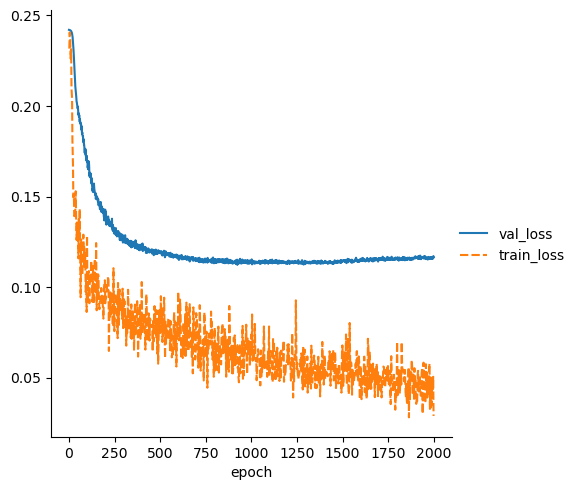

In [42]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_84/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_loss','train_loss']], kind="line")

In [ ]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_84/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_acc','train_acc', 'train_end_acc']], kind="line")

In [ ]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_86/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_loss','train_loss']], kind="line")

In [ ]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_86/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_acc','train_acc', 'train_end_acc']], kind="line")

In [ ]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_115/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_loss','train_loss']], kind="line")

In [ ]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_115/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_acc','train_acc']], kind="line") #, 'train_end_acc']

In [ ]:
#dataset.prepare_data()
dataset.setup(0)
loader = dataset.test_dataloader()
for tensor, label in iter(loader):
     print(tensor,label)

In [ ]:
shap_explainer = shap.DeepExplainer(model,tensor[:25,0,:])
shap_values = shap_explainer.shap_values(tensor[25:52,1,:]) 

In [ ]:
len(shap_values)

In [ ]:
for i in range(0,9):
    shap.summary_plot(shap_values[i], tensor[25:52,0,:], plot_type = 'bar')

In [ ]:
for i in range(0,64):
    shap.group_difference_plot(shap_values[i],label[25:52].numpy().astype('float'))

In [ ]:
test_incorrect = torch.load('/home/vicenteamado/storage/projects/deepthought/data/misclassified_samples/misclassified_samples_epoch99.pt', map_location='cpu')

In [ ]:
test_incorrect

In [ ]:
incorrect_samples = test_incorrect['samples'][0]
full_samples =  TensorDataset(torch.cat([torch.unsqueeze(torch.tensor(author1_embed, dtype = torch.float32), axis = 1),
               torch.unsqueeze(torch.tensor(author2_embed, dtype = torch.float32), axis = 1)], axis = 1),
               torch.tensor(author_references.label.to_list(), dtype=torch.bool)).tensors[0]

In [ ]:
matching_indexes = np.where(np.all(incorrect_samples.numpy()[:, np.newaxis] == full_samples.numpy(), axis=-1))

In [ ]:
author_references.iloc[np.array(list(set(matching_indexes[0])))]

In [ ]:
for i in author_references.iloc[np.array(list(set(matching_indexes[0])))].iterrows():
    print(i[1]['abstract'])
    print(i[1]['author'])
    print(i[1]['abstract2'])
    print(i[1]['author2'])
    print(i[1]['label'])

In [ ]:
with open("output.txt", "w") as output_file:
    for i in author_references.iloc[np.array(list(set(matching_indexes[0])))].iterrows():
        output_file.write(i[1]['abstract'] + "\n")
        output_file.write(i[1]['author'] + "\n")
        output_file.write(i[1]['abstract2'] + "\n")
        output_file.write(i[1]['author2'] + "\n")
        output_file.write(str(i[1]['label']) + "\n")